# Modelo proposto pelas IAs CLAUDE E CHATGPT
## Identificação de Compressão de Volatilidade

Este modelo, é a tentantiva de sinalizar oportunidades de  entradas quando a volatildiade esta baixa.
Sugestão de montagem de Travas, Short Butterfly, Long Strangles, Straddle  ,  Iron Condor Reverso
Acreditando que as opçoes estao baratas, e a vol ira aumentar, compramos essas estruturas

## FUNÇÕES - Modelo Chat GPT

In [ ]:
# Importar Todas as Funções
from OPCOES_ExplosaoVol_CLAUDE_GPT_novo import *

# Rodar Funções

Baixando PETR4.SA...


C:\Users\Usuário\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Usuário\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


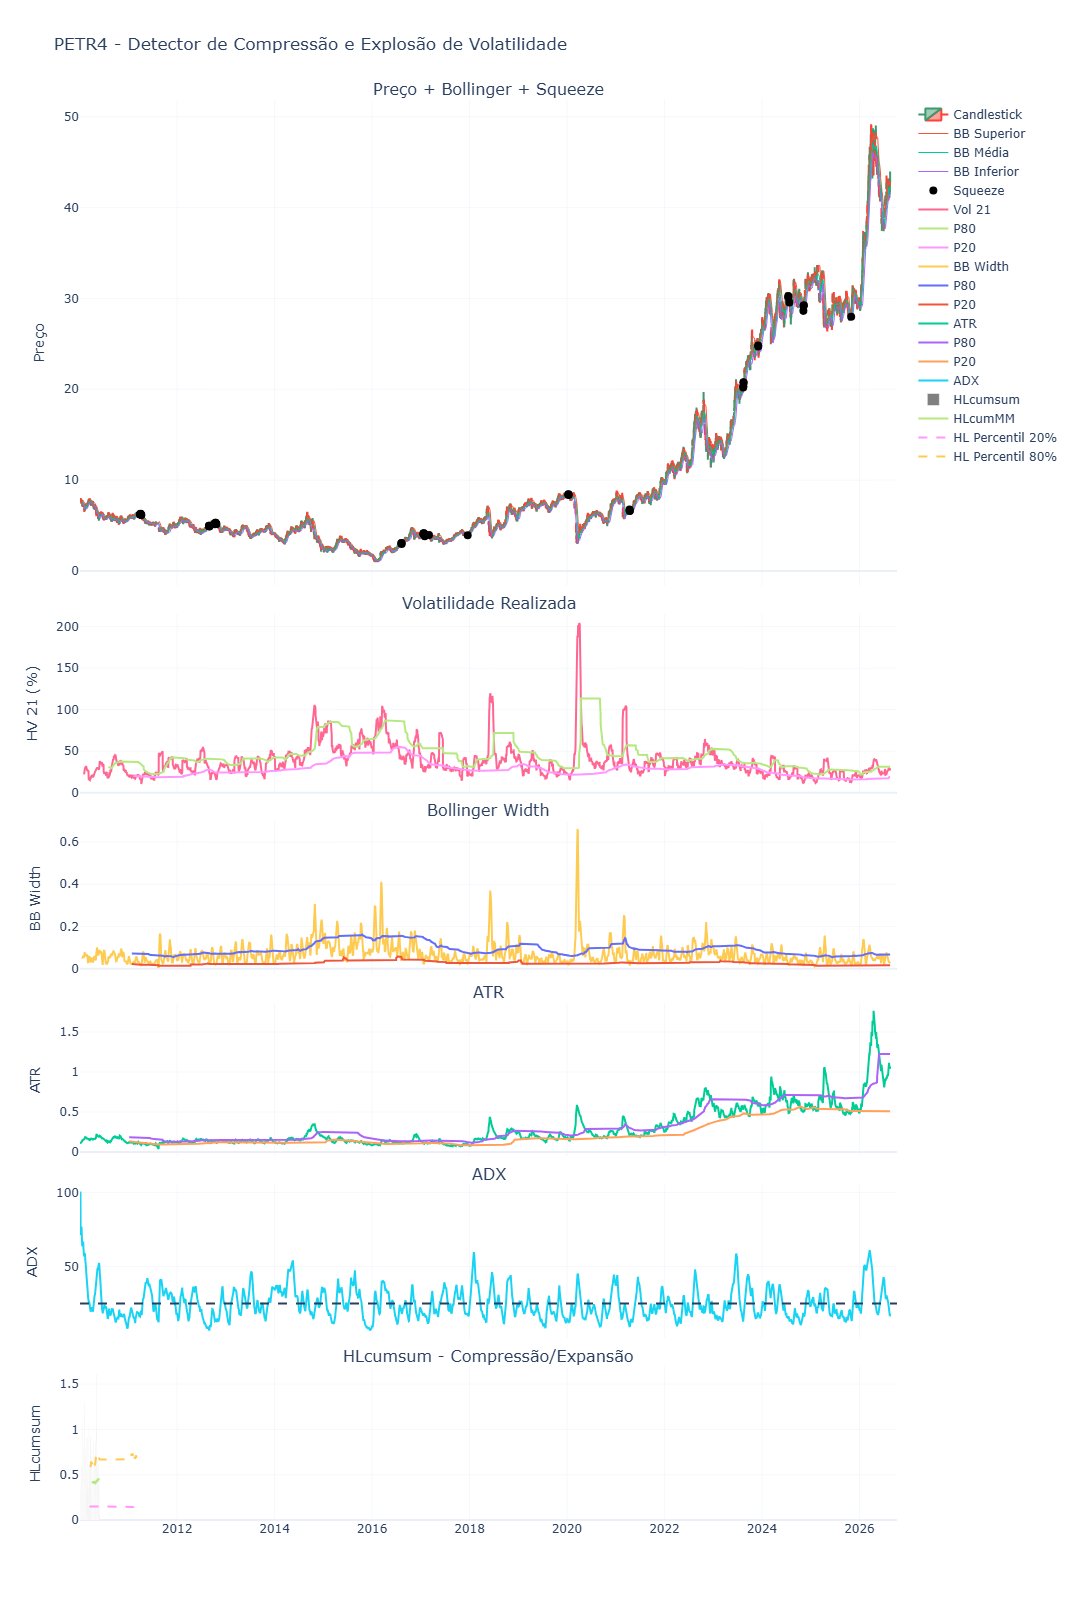

In [492]:
# Importar Todas as Funções
from OPCOES_ExplosaoVol_CLAUDE_GPT_novo import *
# coletar ticker =======================================================
from pathlib import Path
import sys

import MetaTrader5 as mt5
import multiprocessing
import os
import time
from concurrent.futures import ThreadPoolExecutor

# Pasta raiz do projeto (um nível acima de Testes)
projeto = Path.cwd().parent

if str(projeto) not in sys.path:
    sys.path.insert(0, str(projeto))


tf = mt5.TIMEFRAME_H1 # TIME FRAME
cotacoes = 30000
NaN_Maximo = 0

tiker = 'PETR4'

# ==========================================================
# PARÂMETROS QUE DEFINEM AS ENTRADAS (SQUEEZE / EXPLOSÃO)
# Altere os valores abaixo para testar outras configurações.
# ==========================================================
VOL21_PERCENTIL     = 0.2   # percentil mínimo de VOL_21 (0 a 1)
VOL21_JANELA        = 252    # janela (candles) do rolling do percentil
BB_WIDTH_PERCENTIL  = 0.02   # percentil mínimo de BB Width (0 a 1)
BB_WIDTH_JANELA     = 252    # janela (candles) do rolling do percentil
ADX_MINIMO          = 20     # ADX mínimo para squeeze (trend forte)
ATR_CONTRACAO_MULT  = 10.9   # divisor do ATR p/ sinal de explosão (contração)

# COELTAR COM YFINANCE ===================================================
#df = carregar_dados(ticker= "BTC-USD", start="2010-01-01", end=None)
df = carregar_dados(ticker= tiker+".SA", start="2010-01-01", end=None)
# COLETAR COM METATRADER =================================================
#df = cotacoes_mt5_OHLC(tiker, timeframe=tf, n_barras=cotacoes)
# ========================================================================

# Rodar Função ===========================================================
#df_squeeze = detectar_squeeze(df)
df_squeeze = detectar_squeeze(
    df,
    VOL21_PERCENTIL,
    VOL21_JANELA,
    BB_WIDTH_PERCENTIL,
    BB_WIDTH_JANELA,
    ADX_MINIMO,
    ATR_CONTRACAO_MULT)

#relatorio(df_squeeze)

# Plotar Gráficos
plotar_interativo(df_squeeze, tiker)

In [493]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

dias_posicionado = 15
bt = backtest_squeeze(df_squeeze, holding_period = dias_posicionado)

print(f"Retorno médio........: {bt['Retorno %'].mean():.2f}%")
print(f"Movimento médio......: {bt['Retorno %'].abs().mean():.2f}%")
print(f"Mediana..............: {bt['Retorno %'].median():.2f}%")
print(f"Acerto...............: {(bt['Retorno %'] > 0).mean()*100:.1f}%")

df["Ret_Log"] = np.log(df["Close"] / df["Close"].shift(1))
print(f'Variação Média.......: {(df["Ret_Log"].abs()).mean().round(2)}%')
print(len(bt), 'Numero de Trades')
print(dias_posicionado, 'Dias Posicionado')
print(len(bt[bt['Resultado'] == 'Gain']), 'Numero de Gains')
print(len(bt[bt['Resultado'] == 'Loss']), 'Numero de Loss')
print((len(bt[bt['Resultado'] == 'Gain']) / len(bt[bt['Resultado'] == 'Loss'])))

# Verificar sinal de entrada (Squeeze / Explosão) ======================
sinal = verificar_sinal_entrada(df_squeeze, ticker=tiker)

display(bt)

Retorno médio........: 0.45%
Movimento médio......: 6.94%
Mediana..............: -1.06%
Acerto...............: 45.1%
Variação Média.......: 0.02%
51 Numero de Trades
15 Dias Posicionado
23 Numero de Gains
28 Numero de Loss
0.8214285714285714

SINAL DE ENTRADA - PETR4
Data do último candle: 2026-08-19 00:00:00
Close.................: 43.11
ADX...................: 17.60
Squeeze (último candle): False
Explosão (último candle): False

>>> SEM SINAL DE ENTRADA no momento <<<



Price,Open,High,Low,Close,VOL_21,ADX,squeeze,Data Saída,Saída,Retorno %,Resultado
Date,,,,,,,,,,,
2011-03-29,6.238582,6.238582,6.238582,6.238582,0.169541,16.133076,True,2011-04-19,5.662036,-9.241622,Loss
2011-03-30,6.249585,6.293596,6.218777,6.238582,0.169054,16.627433,True,2011-04-20,5.785270,-7.266265,Loss
2011-03-31,6.275993,6.282594,6.227581,6.242985,0.169064,17.086478,True,2011-04-25,5.761063,-7.719411,Loss
2011-04-01,6.242985,6.242985,6.242985,6.242985,0.164998,17.512735,True,2011-04-26,5.765464,-7.648913,Loss
2011-04-04,6.337609,6.348612,6.284795,6.295798,0.149745,18.906334,True,2011-04-27,5.664237,-10.031480,Loss
2011-04-07,6.190170,6.216576,6.099947,6.161562,0.156931,18.835947,True,2011-05-02,5.690320,-7.648107,Loss
2011-04-08,6.172565,6.192370,6.113150,6.163763,0.105016,17.571826,True,2011-05-03,5.628397,-8.685694,Loss
2012-08-27,4.946821,4.974729,4.891003,4.970078,0.268653,7.188493,True,2012-09-18,5.395685,8.563391,Gain
2012-08-28,4.944494,4.997985,4.944494,4.981705,0.268226,6.713228,True,2012-09-19,5.272422,5.835695,Gain


In [485]:
import numpy as np

n_sorteios = 100
df_valid = df.iloc[:-dias_posicionado].copy()

retornos = []
for _ in range(n_sorteios):
    idx = np.random.choice(df_valid.index)
    preco_atual = df.loc[idx, "Close"]
    pos = df.index.get_loc(idx)
    preco_futuro = df.iloc[pos + dias_posicionado]["Close"]
    retorno = (preco_futuro / preco_atual) - 1
    retornos.append(retorno)
media_absoluta = np.mean(np.abs(retornos))

print(f"Média absoluta dos retornos: {media_absoluta:.4%}")
print(f"Média absoluta dos retornos: {media_absoluta * 100:.2f}%")

Média absoluta dos retornos: 8.1183%
Média absoluta dos retornos: 8.12%


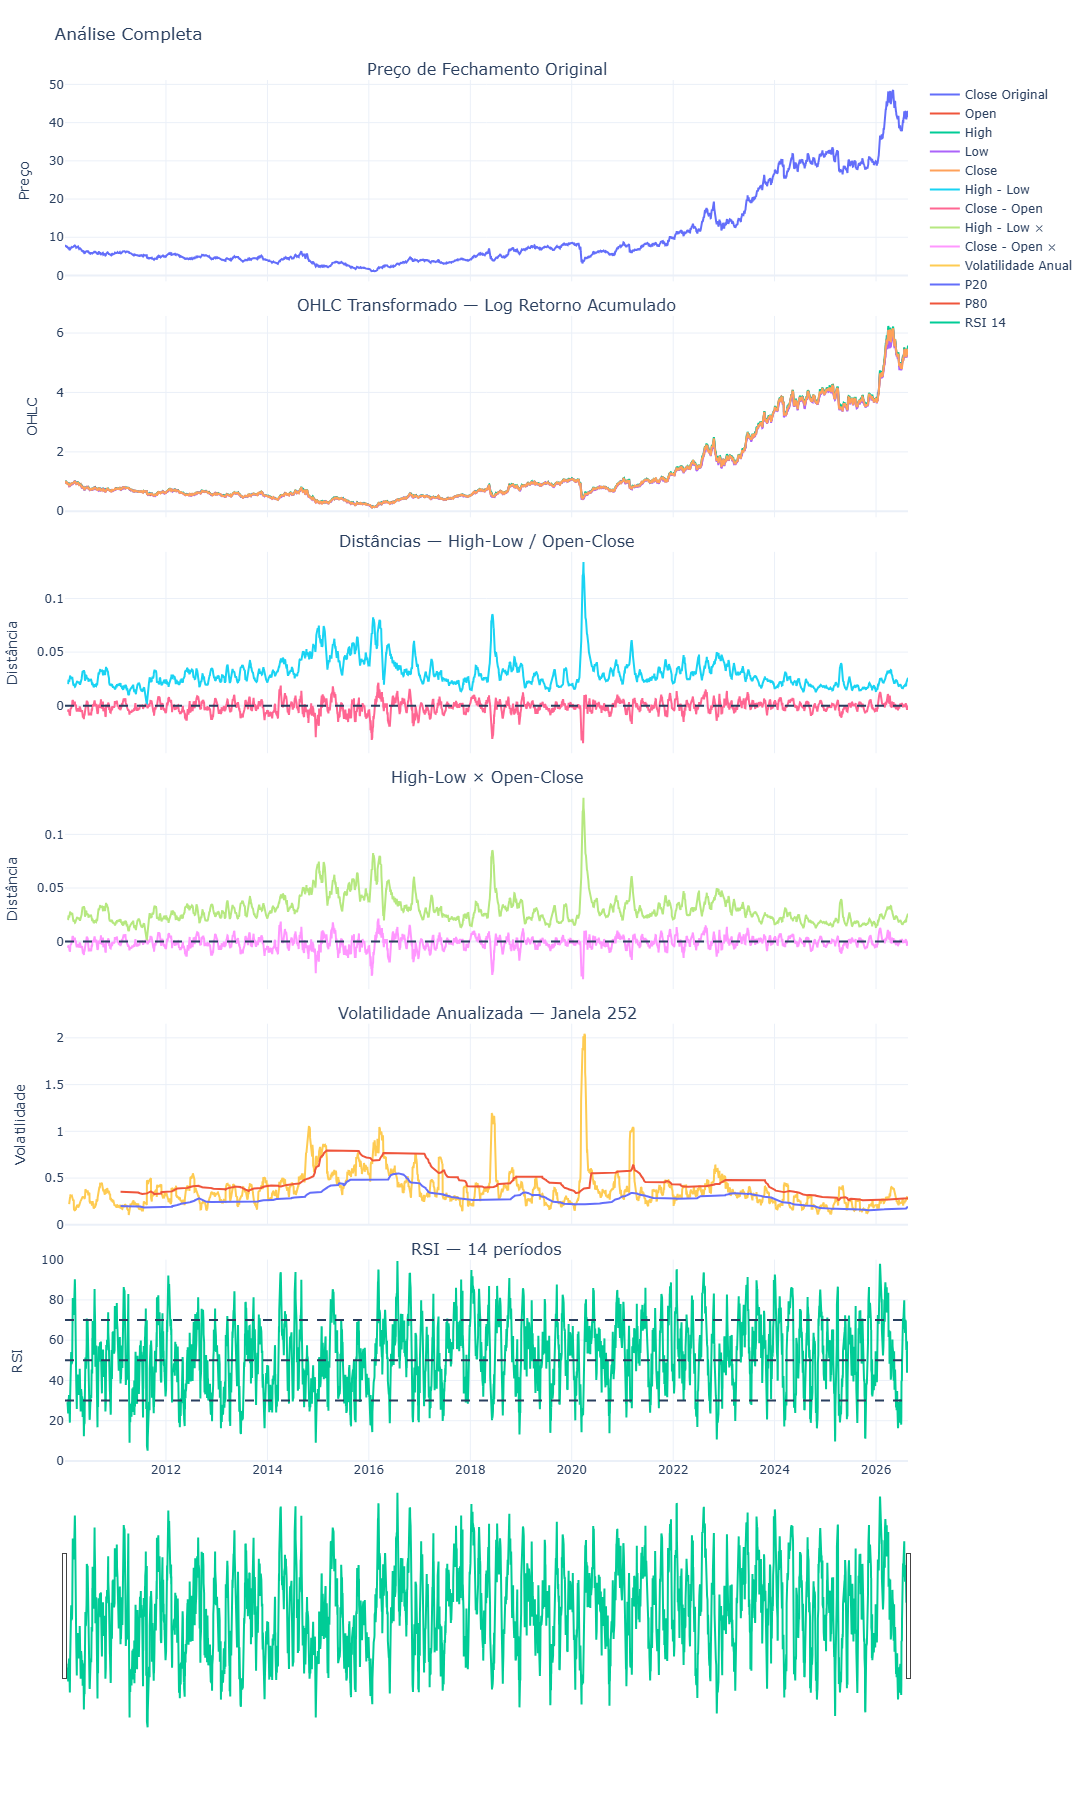

In [498]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = df.copy()
# ============================================================
# PARÂMETROS
# ============================================================

periodos_dist = 14
janela = 252
rsi_periodos = 14


# ============================================================
# 1. LOG-RETORNO ACUMULADO
# ============================================================

# Close:
# mantém exatamente a lógica original

data["Close_log"] = (
    np.log(
        data["Close"] /
        data["Close"].shift(1)
    )
    .cumsum()
)


# Open, High e Low:
# ficam relacionados ao Close do mesmo período

data["Open_log"] = (
    data["Close_log"] +
    np.log(
        data["Open"] /
        data["Close"]
    )
)

data["High_log"] = (
    data["Close_log"] +
    np.log(
        data["High"] /
        data["Close"]
    )
)

data["Low_log"] = (
    data["Close_log"] +
    np.log(
        data["Low"] /
        data["Close"]
    )
)


# ============================================================
# 2. DISTÂNCIA HIGH - LOW
# ============================================================

data["Dist_HL"] = (
    data["High_log"] -
    data["Low_log"]
)

data["Dist_HL_14"] = (
    data["Dist_HL"]
    .rolling(periodos_dist)
    .mean()
)


# ============================================================
# 3. DISTÂNCIA OPEN - CLOSE
# ============================================================

data["Dist_OC"] = (
    data["Close_log"] -
    data["Open_log"]
)

data["Dist_OC_14"] = (
    data["Dist_OC"]
    .rolling(periodos_dist)
    .mean()
)


# ============================================================
# 4. DISTÂNCIA HIGH - LOW EM %
# ============================================================

data["Dist_HL_pct"] = (
    np.exp(data["High_log"] - data["Low_log"]) - 1
)

data["Dist_HL_pct_14"] = (
    data["Dist_HL_pct"]
    .rolling(periodos_dist)
    .mean()
)


# ============================================================
# 5. DISTÂNCIA OPEN - CLOSE EM %
# ============================================================

data["Dist_OC_pct"] = (
    np.exp(data["Close_log"] - data["Open_log"]) - 1
)

data["Dist_OC_pct_14"] = (
    data["Dist_OC_pct"]
    .rolling(periodos_dist)
    .mean()
)


# ============================================================
# 6. RETORNO LOGARÍTMICO
# ============================================================

data["Retorno"] = (
    np.log(
        data["Close"] /
        data["Close"].shift(1)
    )
)


# ============================================================
# 7. VOLATILIDADE ANUALIZADA
# ============================================================

data["Vol_Anual"] = (
    data["Retorno"]
    .rolling(21)
    .std()
    * np.sqrt(252)
)


# ============================================================
# 8. QUARTIL 20% DA VOLATILIDADE
# ============================================================

data["Vol_P20"] = (
    data["Vol_Anual"]
    .rolling(janela)
    .quantile(0.20)
)


# ============================================================
# 9. QUARTIL 80% DA VOLATILIDADE
# ============================================================

data["Vol_P80"] = (
    data["Vol_Anual"]
    .rolling(janela)
    .quantile(0.80)
)


# ============================================================
# 10. RSI 14
# ============================================================

delta = data["Close"].diff()

ganhos = delta.clip(
    lower=0
)

perdas = -delta.clip(
    upper=0
)

media_ganhos = (
    ganhos
    .rolling(rsi_periodos)
    .mean()
)

media_perdas = (
    perdas
    .rolling(rsi_periodos)
    .mean()
)

rs = (
    media_ganhos /
    media_perdas
)

data["RSI_14"] = (
    100 -
    (
        100 /
        (1 + rs)
    )
)


# ============================================================
# 11. RECONSTRUIR OHLC TRANSFORMADO
# ============================================================

data["Open_transformado"] = (
    np.exp(data["Open_log"])
)

data["High_transformado"] = (
    np.exp(data["High_log"])
)

data["Low_transformado"] = (
    np.exp(data["Low_log"])
)

data["Close_transformado"] = (
    np.exp(data["Close_log"])
)


# ============================================================
# 12. GRÁFICO — OHLC ORIGINAL
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=6,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.025,
    subplot_titles=[
        "Preço de Fechamento Original",
        "OHLC Transformado — Log Retorno Acumulado",
        "Distâncias — High-Low / Open-Close",
        "High-Low × Open-Close",
        "Volatilidade Anualizada — Janela 252",
        "RSI — 14 períodos"
    ]
)

# ============================================================
# 1. CLOSE ORIGINAL
# ============================================================

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Close"],
        name="Close Original"
    ),
    row=1, col=1
)


# ============================================================
# 2. OHLC TRANSFORMADO
# ============================================================

for coluna, nome in [
    ("Open_transformado", "Open"),
    ("High_transformado", "High"),
    ("Low_transformado", "Low"),
    ("Close_transformado", "Close")
]:

    fig.add_trace(
        go.Scatter(
            x=data.index,
            y=data[coluna],
            name=nome
        ),
        row=2, col=1
    )


# ============================================================
# 3. DISTÂNCIAS
# ============================================================

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Dist_HL_14"],
        name="High - Low"
    ),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Dist_OC_14"],
        name="Close - Open"
    ),
    row=3, col=1
)

fig.add_hline(
    y=0,
    line_dash="dash",
    row=3,
    col=1
)


# ============================================================
# 4. HIGH-LOW × OPEN-CLOSE
# ============================================================

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Dist_HL_14"],
        name="High - Low ×"
    ),
    row=4, col=1
)

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Dist_OC_14"],
        name="Close - Open ×"
    ),
    row=4, col=1
)

fig.add_hline(
    y=0,
    line_dash="dash",
    row=4,
    col=1
)


# ============================================================
# 5. VOLATILIDADE
# ============================================================

for coluna, nome in [
    ("Vol_Anual", "Volatilidade Anual"),
    ("Vol_P20", "P20"),
    ("Vol_P80", "P80")
]:

    fig.add_trace(
        go.Scatter(
            x=data.index,
            y=data[coluna],
            name=nome
        ),
        row=5, col=1
    )


# ============================================================
# 6. RSI
# ============================================================

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["RSI_14"],
        name="RSI 14"
    ),
    row=6, col=1
)

for nivel in [30, 50, 70]:

    fig.add_hline(
        y=nivel,
        line_dash="dash",
        row=6,
        col=1
    )


# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(
    title="Análise Completa",
    template="plotly_white",
    height=1800,
    hovermode="x unified",
    margin=dict(
        l=60,
        r=30,
        t=80,
        b=60
    )
)

fig.update_yaxes(title_text="Preço", row=1, col=1)
fig.update_yaxes(title_text="OHLC", row=2, col=1)
fig.update_yaxes(title_text="Distância", row=3, col=1)
fig.update_yaxes(title_text="Distância", row=4, col=1)
fig.update_yaxes(title_text="Volatilidade", row=5, col=1)
fig.update_yaxes(title_text="RSI", range=[0, 100], row=6, col=1)

fig.update_xaxes(
    rangeslider=dict(visible=True),
    row=6,
    col=1
)

fig.show()

In [ ]:
bt['Retorno %'][bt['Resultado'] == 'Gain'].mean()

# RODAR VERSÃO - CLAUDE

In [ ]:
# RODAR CODIGO CLAUDE
tiker = 'PETR4'
!python squeeze_detector.py --ticker PETR4.SA --start 2019-01-01 --save grafico.html

Baixando PETR4.SA...
1898 pregões carregados

===== SQUEEZES =====
Price           Close     bb_pct     atr_pct        ADX
Date                                                   
2025-02-06  32.036999   0.793651   14.682540  23.054141
2025-02-07  31.854128   1.984127   15.476190  21.627725
2025-02-10  32.071827   2.380952   11.111111  20.303195
2025-02-11  32.071827   2.380952    6.349206  19.204426
2025-02-12  31.592886   4.365079   11.111111  18.697944
2025-02-14  32.603020   5.555556   21.031746  18.392195
2025-02-17  32.803303   5.952381   17.460317  18.840212
2025-09-19  29.199070   6.349206    1.587302  12.861388
2025-09-22  29.490499   6.349206    2.777778  12.213707
2025-09-23  29.988743   6.349206    5.158730  12.461856
2025-11-04  28.437601   5.158730    9.126984  13.008073
2026-01-07  28.928410  10.317460   30.158730  21.744317
2026-01-08  29.287228  10.714286   30.555556  21.012315
2026-01-09  29.384205  10.317460   32.936508  19.551382
2026-01-12  29.442392   9.126984   24

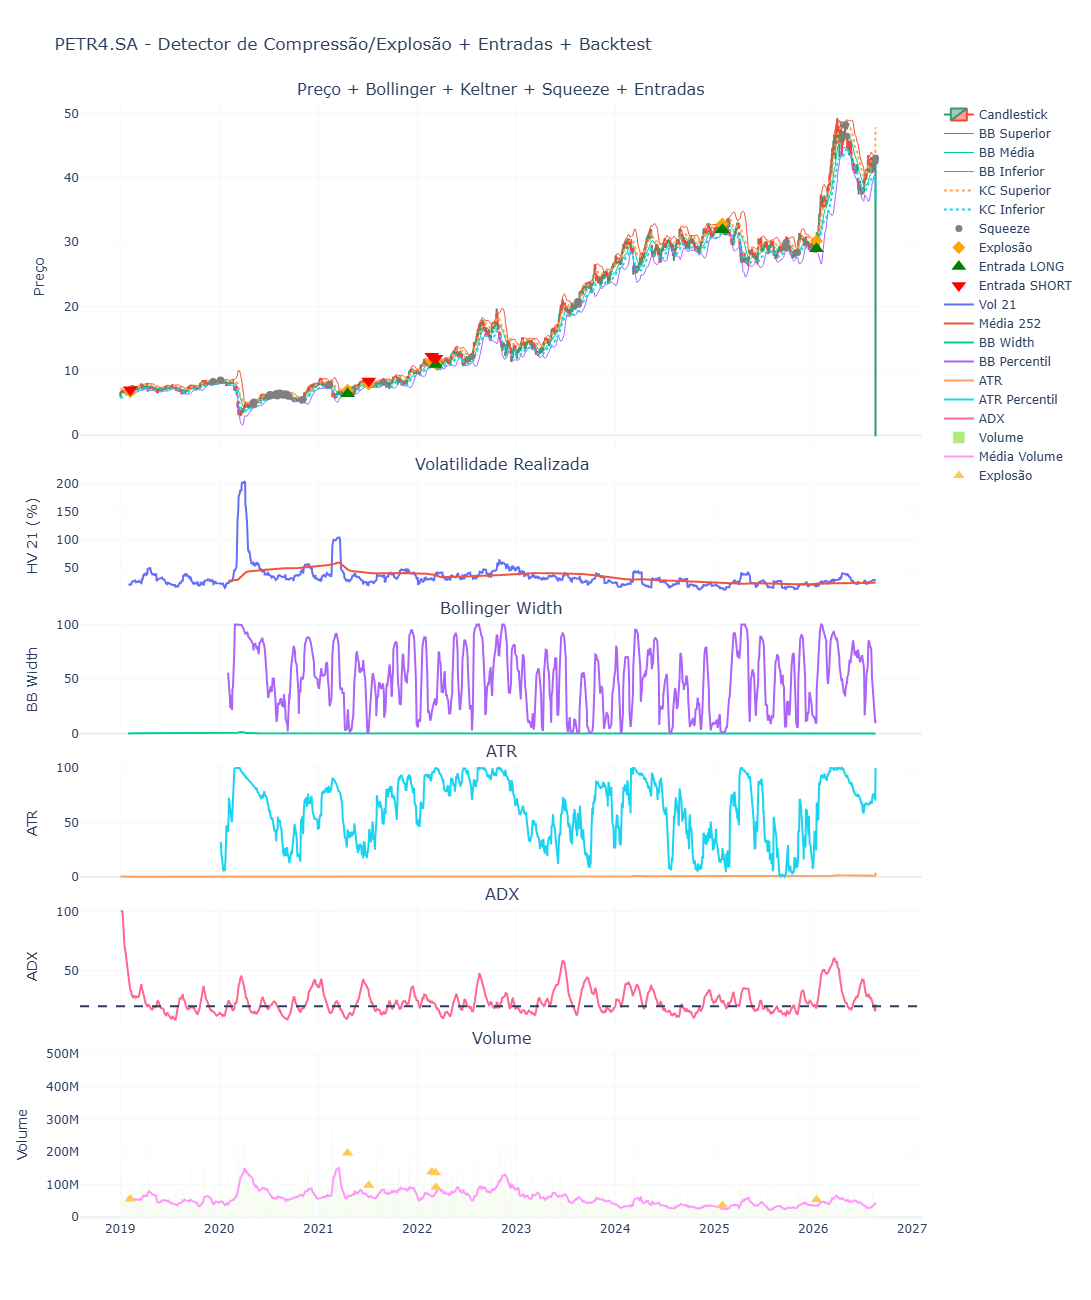

In [20]:
# RODAR CODIGO CLAUDE
# ============================================================
# Detector de Compressão / Explosão de Volatilidade
# Versão Jupyter + Yahoo Finance
# + Sinalização de entradas + Backtest parametrizável
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ============================================================
# ================  PARÂMETROS (ALTERE AQUI)  ================
# Todos os parâmetros usados para montar os indicadores, definir
# uma entrada e calcular o retorno do backtest ficam aqui fora
# das funções. Mude os valores e rode o notebook de novo para
# testar combinações diferentes, sem precisar mexer no código.
# ============================================================

# --- Dados ---
TICKER = "PETR4.SA"
DATA_INICIO = "2019-01-01"
DATA_FIM = None  # None = até hoje

# --- Bollinger Bands ---
BB_PERIOD = 20
BB_STD = 2

# --- Keltner Channel ---
KC_PERIOD = 20
KC_MULT = 1.5

# --- ATR / ADX ---
ATR_PERIOD = 14
ADX_PERIOD = 14

# --- Percentis (janela de lookback) ---
PERCENTIL_WINDOW = 252

# --- Critério de explosão (rompimento do squeeze) ---
EXPLOSAO_RANGE_MULT = 1.5      # range do candle > mult * ATR
USAR_FILTRO_VOLUME = False     # exigir volume acima da média?
EXPLOSAO_VOLUME_MULT = 1.5     # volume > mult * média de volume (20d)
VOLUME_MEDIA_PERIOD = 20

# --- Critério de direção da entrada ---
# "candle": long se Close > Open no candle de explosão, short caso contrário
# "kc_mid": long se Close > linha média do Keltner, short caso contrário
CRITERIO_DIRECAO = "candle"

# --- Backtest ---
N_PERIODOS_RETORNO = 25   # quantos pregões à frente medir o retorno da entrada
CUSTO_OPERACIONAL = 0.0  # custo percentual por operação (ida+volta). Ex: 0.001 = 0.1%
CAPITAL_POR_TRADE = 1.0  # capital "unitário" alocado por trade (para equity curve)

# ============================================================


# ============================================================
# COLETA DE DADOS YFINANCE
# ============================================================
def carregar_dados(ticker=TICKER, start=DATA_INICIO, end=DATA_FIM):

    print(f"Baixando {ticker}...")

    df = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    # corrige MultiIndex do Yahoo
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Open", "High", "Low", "Close", "Volume"]]
    df.dropna(inplace=True)

    print(f"{len(df)} pregões carregados")
    return df


# ============================================================
# INDICADORES
# ============================================================
def true_range(df):
    prev_close = df["Close"].shift(1)

    tr = pd.concat(
        [
            df["High"] - df["Low"],
            abs(df["High"] - prev_close),
            abs(df["Low"] - prev_close)
        ],
        axis=1
    ).max(axis=1)

    return tr


def ATR(df, period=ATR_PERIOD):
    return true_range(df).ewm(alpha=1 / period, adjust=False).mean()


def bollinger(df, period=BB_PERIOD, std=BB_STD):
    mid = df["Close"].rolling(period).mean()
    desvio = df["Close"].rolling(period).std()

    upper = mid + std * desvio
    lower = mid - std * desvio
    width = (upper - lower) / mid

    return mid, upper, lower, width


def keltner(df, period=KC_PERIOD, mult=KC_MULT, atr_period=ATR_PERIOD):
    mid = df["Close"].ewm(span=period, adjust=False).mean()
    atr = ATR(df, atr_period)

    upper = mid + mult * atr
    lower = mid - mult * atr

    return mid, upper, lower


def ADX(df, period=ADX_PERIOD):
    up = df["High"].diff()
    down = -df["Low"].diff()

    plus = np.where((up > down) & (up > 0), up, 0)
    minus = np.where((down > up) & (down > 0), down, 0)

    atr = ATR(df, period)

    plus_di = pd.Series(plus, index=df.index).ewm(alpha=1 / period).mean() / atr * 100
    minus_di = pd.Series(minus, index=df.index).ewm(alpha=1 / period).mean() / atr * 100

    dx = (abs(plus_di - minus_di) / (plus_di + minus_di)) * 100

    return dx.ewm(alpha=1 / period).mean()


def percentil(series, window=PERCENTIL_WINDOW):
    return series.rolling(window).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100
    )


# ============================================================
# CÁLCULO DO SQUEEZE
# ============================================================
def detectar_squeeze(
    df,
    bb_period=BB_PERIOD,
    bb_std=BB_STD,
    kc_period=KC_PERIOD,
    kc_mult=KC_MULT,
    atr_period=ATR_PERIOD,
    adx_period=ADX_PERIOD,
    percentil_window=PERCENTIL_WINDOW,
    explosao_range_mult=EXPLOSAO_RANGE_MULT,
    usar_filtro_volume=USAR_FILTRO_VOLUME,
    explosao_volume_mult=EXPLOSAO_VOLUME_MULT,
    volume_media_period=VOLUME_MEDIA_PERIOD,
):
    out = df.copy()

    out["bb_mid"], out["bb_up"], out["bb_low"], out["bb_width"] = bollinger(
        out, bb_period, bb_std
    )

    out["kc_mid"], out["kc_up"], out["kc_low"] = keltner(
        out, kc_period, kc_mult, atr_period
    )

    out["ATR"] = ATR(out, atr_period)
    out["ADX"] = ADX(out, adx_period)

    out["bb_pct"] = percentil(out["bb_width"], percentil_window)
    out["atr_pct"] = percentil(out["ATR"], percentil_window)

    # Volatilidade realizada 21 dias anualizada
    retorno_log = np.log(out["Close"] / out["Close"].shift(1))
    out["VOL_21"] = retorno_log.rolling(21).std() * np.sqrt(252)
    out["VOL_MEDIA"] = out["VOL_21"].rolling(252).mean()

    # squeeze clássico
    out["squeeze"] = (out["bb_up"] < out["kc_up"]) & (out["bb_low"] > out["kc_low"])

    out["range"] = out["High"] - out["Low"]
    out["vol_media_volume"] = out["Volume"].rolling(volume_media_period).mean()

    condicao_explosao = out["squeeze"].shift(1) & (
        out["range"] > explosao_range_mult * out["ATR"]
    )

    if usar_filtro_volume:
        condicao_explosao = condicao_explosao & (
            out["Volume"] > explosao_volume_mult * out["vol_media_volume"]
        )

    out["explosao"] = condicao_explosao

    return out


# ============================================================
# SINALIZAÇÃO DE ENTRADAS (LONG / SHORT)
# ============================================================
def sinalizar_entradas(df, criterio_direcao=CRITERIO_DIRECAO):
    """
    Marca as entradas long/short no dia da explosão, com base no
    critério de direção escolhido (CRITERIO_DIRECAO).
    """
    out = df.copy()

    if criterio_direcao == "candle":
        direcao = np.where(out["Close"] > out["Open"], 1, -1)
    elif criterio_direcao == "kc_mid":
        direcao = np.where(out["Close"] > out["kc_mid"], 1, -1)
    else:
        raise ValueError(
            "CRITERIO_DIRECAO deve ser 'candle' ou 'kc_mid'"
        )

    out["direcao"] = direcao

    out["entrada_long"] = out["explosao"] & (out["direcao"] == 1)
    out["entrada_short"] = out["explosao"] & (out["direcao"] == -1)
    out["entrada"] = out["entrada_long"] | out["entrada_short"]

    return out


# ============================================================
# BACKTEST
# ============================================================
def backtest(
    df,
    n_periodos=N_PERIODOS_RETORNO,
    custo=CUSTO_OPERACIONAL,
    capital_por_trade=CAPITAL_POR_TRADE,
):
    """
    Para cada entrada sinalizada, calcula o retorno do preço de
    fechamento após n_periodos pregões (na direção do trade),
    descontando custo operacional. Retorna o df com a coluna de
    retorno futuro e um DataFrame com o detalhe de cada trade.
    """
    out = df.copy()

    # retorno do close daqui a n_periodos (sem considerar direção)
    out["retorno_futuro"] = out["Close"].shift(-n_periodos) / out["Close"] - 1

    entradas = out[out["entrada"]]

    registros = []
    for data_entrada, row in entradas.iterrows():
        if pd.isna(row["retorno_futuro"]):
            continue  # não há candles suficientes à frente ainda

        direcao = 1 if row["entrada_long"] else -1
        retorno_bruto = row["retorno_futuro"] * direcao
        retorno_liquido = retorno_bruto - custo

        registros.append(
            {
                "data_entrada": data_entrada,
                "direcao": "LONG" if direcao == 1 else "SHORT",
                "preco_entrada": row["Close"],
                "n_periodos": n_periodos,
                "retorno_bruto": retorno_bruto,
                "retorno_liquido": retorno_liquido,
                "resultado_capital": capital_por_trade * retorno_liquido,
            }
        )

    trades = pd.DataFrame(registros)
    if not trades.empty:
        trades.set_index("data_entrada", inplace=True)
        trades["equity_acumulado"] = (
            capital_por_trade + trades["resultado_capital"].cumsum()
        )

    return out, trades


# ============================================================
# RELATÓRIO
# ============================================================
def relatorio(df):
    print("\n===== SQUEEZES =====")
    eventos = df[df["squeeze"]]
    print(eventos[["Close", "bb_pct", "atr_pct", "ADX"]].tail(20))

    print("\n===== EXPLOSÕES =====")
    print(df[df["explosao"]][["Close", "Volume"]])


def relatorio_backtest(trades):
    print("\n===== BACKTEST =====")

    if trades.empty:
        print("Nenhum trade encontrado com os parâmetros atuais.")
        return

    n = len(trades)
    vencedores = (trades["retorno_liquido"] > 0).sum()
    win_rate = vencedores / n * 100

    retorno_medio = trades["retorno_liquido"].mean() * 100
    retorno_total = trades["retorno_liquido"].sum() * 100
    melhor = trades["retorno_liquido"].max() * 100
    pior = trades["retorno_liquido"].min() * 100

    print(f"Nº de trades:        {n}")
    print(f"Long / Short:        {(trades['direcao']=='LONG').sum()} / {(trades['direcao']=='SHORT').sum()}")
    print(f"Win rate:            {win_rate:.1f}%")
    print(f"Retorno médio/trade: {retorno_medio:.2f}%")
    print(f"Retorno total (soma):{retorno_total:.2f}%")
    print(f"Melhor trade:        {melhor:.2f}%")
    print(f"Pior trade:          {pior:.2f}%")
    print("\nÚltimos trades:")
    print(
        trades[["direcao", "preco_entrada", "retorno_liquido", "equity_acumulado"]]
        .tail(15)
    )


# ============================================================
# GRÁFICO
# ============================================================
def plotar_interativo(df, ticker, trades=None):
    fig = make_subplots(
        rows=6,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.02,
        row_heights=[0.35, 0.12, 0.12, 0.12, 0.12, 0.17],
        subplot_titles=[
            "Preço + Bollinger + Keltner + Squeeze + Entradas",
            "Volatilidade Realizada",
            "Bollinger Width",
            "ATR",
            "ADX",
            "Volume",
        ],
    )

    # CANDLESTICK
    fig.add_trace(
        go.Candlestick(
            x=df.index, open=df["Open"], high=df["High"],
            low=df["Low"], close=df["Close"], name="Candlestick"
        ),
        row=1, col=1
    )

    # BOLLINGER
    fig.add_trace(go.Scatter(x=df.index, y=df["bb_up"], mode="lines",
                              line=dict(width=1), name="BB Superior"), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["bb_mid"], mode="lines",
                              line=dict(width=1), name="BB Média"), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["bb_low"], mode="lines",
                              line=dict(width=1), name="BB Inferior"), row=1, col=1)

    # KELTNER
    fig.add_trace(go.Scatter(x=df.index, y=df["kc_up"], mode="lines",
                              line=dict(dash="dot"), name="KC Superior"), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["kc_low"], mode="lines",
                              line=dict(dash="dot"), name="KC Inferior"), row=1, col=1)

    # SQUEEZE
    sq = df[df["squeeze"]]
    fig.add_trace(
        go.Scatter(x=sq.index, y=sq["Close"], mode="markers",
                    marker=dict(size=7, symbol="circle", color="gray"), name="Squeeze"),
        row=1, col=1
    )

    # EXPLOSÃO (evento bruto, sem direção)
    ex = df[df["explosao"]]
    fig.add_trace(
        go.Scatter(x=ex.index, y=ex["Close"], mode="markers",
                    marker=dict(size=10, symbol="diamond", color="orange"), name="Explosão"),
        row=1, col=1
    )

    # ENTRADAS LONG
    long_e = df[df["entrada_long"]]
    fig.add_trace(
        go.Scatter(
            x=long_e.index, y=long_e["Low"] * 0.985, mode="markers",
            marker=dict(size=13, symbol="triangle-up", color="green"),
            name="Entrada LONG"
        ),
        row=1, col=1
    )

    # ENTRADAS SHORT
    short_e = df[df["entrada_short"]]
    fig.add_trace(
        go.Scatter(
            x=short_e.index, y=short_e["High"] * 1.015, mode="markers",
            marker=dict(size=13, symbol="triangle-down", color="red"),
            name="Entrada SHORT"
        ),
        row=1, col=1
    )

    # VOLATILIDADE
    fig.add_trace(go.Scatter(x=df.index, y=df["VOL_21"] * 100, mode="lines", name="Vol 21"), row=2, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["VOL_MEDIA"] * 100, mode="lines", name="Média 252"), row=2, col=1)

    # BOLLINGER WIDTH
    fig.add_trace(go.Scatter(x=df.index, y=df["bb_width"], mode="lines", name="BB Width"), row=3, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["bb_pct"], mode="lines", name="BB Percentil"), row=3, col=1)

    # ATR
    fig.add_trace(go.Scatter(x=df.index, y=df["ATR"], mode="lines", name="ATR"), row=4, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["atr_pct"], mode="lines", name="ATR Percentil"), row=4, col=1)

    # ADX
    fig.add_trace(go.Scatter(x=df.index, y=df["ADX"], mode="lines", name="ADX"), row=5, col=1)
    fig.add_hline(y=20, line_dash="dash", row=5, col=1)

    # VOLUME
    fig.add_trace(go.Bar(x=df.index, y=df["Volume"], name="Volume"), row=6, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["vol_media_volume"], mode="lines", name="Média Volume"), row=6, col=1)
    fig.add_trace(
        go.Scatter(x=ex.index, y=ex["Volume"], mode="markers",
                    marker=dict(size=10, symbol="triangle-up"), name="Explosão"),
        row=6, col=1
    )

    # EIXOS
    fig.update_yaxes(title="Preço", row=1, col=1)
    fig.update_yaxes(title="HV 21 (%)", row=2, col=1)
    fig.update_yaxes(title="BB Width", row=3, col=1)
    fig.update_yaxes(title="ATR", row=4, col=1)
    fig.update_yaxes(title="ADX", row=5, col=1)
    fig.update_yaxes(title="Volume", row=6, col=1)

    # LAYOUT
    fig.update_layout(
        title=f"{ticker} - Detector de Compressão/Explosão + Entradas + Backtest",
        height=1300,
        hovermode="x unified",
        template="plotly_white",
        xaxis_rangeslider_visible=False,
    )

    fig.update_xaxes(showgrid=True, gridwidth=0.5)
    fig.update_yaxes(showgrid=True, gridwidth=0.5)

    fig.update_traces(hovertemplate="<b>%{x}</b><br>Valor: %{y:.2f}<extra></extra>")

    fig.show()


# ============================================================
# EXECUÇÃO
# ============================================================
if __name__ == "__main__":
    dados = carregar_dados(TICKER, DATA_INICIO, DATA_FIM)

    resultado = detectar_squeeze(dados)
    resultado = sinalizar_entradas(resultado)

    resultado, trades = backtest(resultado)

    relatorio(resultado)
    relatorio_backtest(trades)

    plotar_interativo(resultado, TICKER, trades)